# **Training models**

### **Library imports and creation of the baseline**

In this section, we define the criteria for determining user satisfaction. Using the rating variable, we establish that a film is classified as 'liked' by the community if its score is 3.5 or higher; otherwise, it is classified as negative or neutral. Following this target definition, we separate the data into input features and output labels to prepare them for the training stage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

print("Loading data")
df = pd.read_pickle("data_processed.pkl")
df['text_content'] = df['text_content'].fillna("")

# We define if a film was liked by getting films which rating was above 3.5
df['is_liked'] = (df['rating'] >= 3.5).astype(int)

# We save columns into global variables that we will use during training.
X = df['text_content']
y = df['is_liked']

print(f"Size of the Dataset: {len(df)}")
print(f"Distribution of reviews - Positives (1): {y.sum()} | Negatives (0): {len(df) - y.sum()}")

Loading data
Size of the Dataset: 284234
Distribution of reviews - Positives (1): 212857 | Negatives (0): 71377


## **Textual Model training**

We separate the tests and training set for the text data

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"• Training set (X_train): {X_train.shape[0]}")
print(f"• Test set (X_test): {X_test.shape[0]} ")

• Training set (X_train): 227387
• Test set (X_test): 56847 


#### **Bag of words and training**

We apply Bag of Words (BoW) vectorization via CountVectorizer to transform our raw text data into numerical features, keeping a maximum of 5,000 terms. We then fit two baseline classification models on this representation: Naive Bayes and Logistic Regression (configured with 1,000 iterations to ensure convergence). Finally, both models generate predictions on the test set to establish our baseline performance for textual data.

In [3]:
# Vectorization of the dataset
print("Vectorizing with Bag of Words (BoW)...")
bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

# 1. Naive Bayes with BoW
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
preds_nb_bow = nb_bow.predict(X_test_bow)

# 2. Logistic regression with BoW
lr_bow = LogisticRegression(max_iter=1000)
lr_bow.fit(X_train_bow, y_train)
preds_lr_bow = lr_bow.predict(X_test_bow)

print("Models trained with Bag of Words.")

Vectorizing with Bag of Words (BoW)...
Models trained with Bag of Words.


#### **Tfid vectorizer and training**



We upgrade our feature extraction using TfidfVectorizer with a 5,000-word limit. Unlike Bag of Words, TF-IDF penalizes generic words and rewards highly specific, meaningful terms. We then fit Naive Bayes and Logistic Regression onto this new feature space and generate predictions on the test set. This allows us to directly compare the efficacy of frequency-based vs. importance-based text vectorization methods.

In [4]:
print("Vectorizing with TF-IDF...")
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# 1. Naive Bayes with TF-IDF
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
preds_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

# 2. Logistic regression with TF-IDF
lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(X_train_tfidf, y_train)
preds_lr_tfidf = lr_tfidf.predict(X_test_tfidf)

print("Models trained with TF-IDF.")

Vectorizing with TF-IDF...
Models trained with TF-IDF.


#### **Doc2 vectorizer and training**


We use Doc2Vec to transform full text reviews into numerical vectors. First, we convert the text into tagged documents to train the model for 10 epochs. To save time and memory on the large dataset, we extract the training vectors directly from the model weights. For the test set, we calculate new vectors using only 5 epochs. Finally, we train a Logistic Regression model on these vectors to make the final predictions.

In [10]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.linear_model import LogisticRegression
import numpy as np

print("Vectorizing with Doc2Vec...")

# Prepare tagged documents for Gensim formatting
tagged_train = [TaggedDocument(words=str(text).split(), tags=[i]) for i, text in enumerate(X_train)]
tagged_test = [TaggedDocument(words=str(text).split(), tags=[i]) for i, text in enumerate(X_test)]

# Match workers to Google Colab's standard 2-core CPU environment to avoid overhead
d2v_model = Doc2Vec(vector_size=100, window=5, min_count=2, workers=2, epochs=10)
d2v_model.build_vocab(tagged_train)
d2v_model.train(tagged_train, total_examples=d2v_model.corpus_count, epochs=d2v_model.epochs)

print("Extracting and inferring vectors...")
# Optimization: Extract trained vectors directly from the model for the training set.
# This prevents executing infer_vector 227,000 times sequentially or via joblib.
X_train_d2v = np.vstack([d2v_model.dv[i] for i in range(len(tagged_train))])

# Sequentially infer vectors only for the smaller test set using standard internal loops
X_test_d2v = np.array([d2v_model.infer_vector(doc.words, epochs=5) for doc in tagged_test])

print("Training Logistic Regression classifier on top of Doc2Vec features...")
# Using 'lbfgs' solver to effectively manage the large sample matrix
lr_d2v = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
lr_d2v.fit(X_train_d2v, y_train)
preds_lr_d2v = lr_d2v.predict(X_test_d2v)

print("Models trained successfully with Doc2Vec embeddings.")

Vectorizing with Doc2Vec...
Extracting and inferring vectors...
Training Logistic Regression classifier on top of Doc2Vec features...
Models trained successfully with Doc2Vec embeddings.


#### **BERT vectorizer and training**


We use a pre-trained BERT model to extract contextual vectors from the text. Because BERT is very heavy, we restrict the data to a small sample of 1,500 training and 1,500 test reviews. We process the text in batches and set a maximum length of 128 tokens. Then, we use a Mean Pooling operation to calculate a single vector for each review. Finally, we train a Logistic Regression model on these vectors to get our predictions.

In [11]:
from transformers import BertTokenizer, BertModel
import torch
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
import numpy as np

print("Vectorizing with BERT (using optimized Batch Mean Pooling)...")

# Configure the sample size for your local computer environment
SAMPLE_SIZE = 1500
X_train_bert_sample = list(X_train[:SAMPLE_SIZE])
y_train_bert_sample = y_train[:SAMPLE_SIZE]
X_test_bert_sample = list(X_test[:SAMPLE_SIZE])
y_test_bert_sample = y_test[:SAMPLE_SIZE]

# Safely detect the CPU or GPU device based on your environment setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"We use the following device: {device}")

# Load the official tokenizer and BERT model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased').to(device)
bert_model.eval()

def get_bert_mean_pooling_embeddings(text_list, batch_size=32):
    all_embeddings = []

    # Batch processing with progress bar
    for i in tqdm(range(0, len(text_list), batch_size), desc="BERT embeddings extraction"):
        batch_texts = text_list[i:i+batch_size]

        # Standard tokenization requested in the project guidelines
        inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = bert_model(**inputs)

        token_embeddings = outputs.last_hidden_state
        mask = inputs['attention_mask'].unsqueeze(-1)

        # Mathematical Mean Pooling operation (batch average ignoring padding tokens)
        sum_embeddings = torch.sum(token_embeddings * mask, dim=1)
        sum_mask = torch.clamp(mask.sum(dim=1), min=1e-9)
        mean_pooled = sum_embeddings / sum_mask

        all_embeddings.append(mean_pooled.cpu().numpy())

    return np.vstack(all_embeddings)

print(f"\nProcessing {len(X_train_bert_sample)} Train samples...")
X_train_bert = get_bert_mean_pooling_embeddings(X_train_bert_sample)

print(f"\nProcessing {len(X_test_bert_sample)} Test samples...")
X_test_bert = get_bert_mean_pooling_embeddings(X_test_bert_sample)

print(f"Shape of X_train_bert: {X_train_bert.shape}")

# Training Logistic Regression classifier (Step 5 of the project)
print("\nTraining Logistic Regression classifier on top of BERT features...")
lr_bert = LogisticRegression(max_iter=1000, random_state=42)
lr_bert.fit(X_train_bert, y_train_bert_sample)
preds_lr_bert = lr_bert.predict(X_test_bert)

print("Success: Pipeline completed using official BERT batch mean pooling.")

Vectorizing with BERT (using optimized Batch Mean Pooling)...
We use the following device: cpu


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...


Processing 1500 Train samples...


BERT embeddings extraction: 100%|██████████| 47/47 [09:42<00:00, 12.40s/it]



Processing 1500 Test samples...


BERT embeddings extraction: 100%|██████████| 47/47 [09:17<00:00, 11.85s/it]


Shape of X_train_bert: (1500, 768)

Training Logistic Regression classifier on top of BERT features...
Success: Pipeline completed using official BERT batch mean pooling.


### **Learning curve for text models**

This section generates a $3 \times 2$ grid of learning curves to visually monitor and analyze convergence patterns across all textual classification pipelines.

Computing Learning Curve for BoW + Naive Bayes...
Computing Learning Curve for BoW + Logistic Regression...
Computing Learning Curve for TF-IDF + Naive Bayes...
Computing Learning Curve for TF-IDF + Logistic Regression...
Computing Learning Curve for Doc2Vec + Logistic Regression...
Computing Learning Curve for BERT + Logistic Regression...


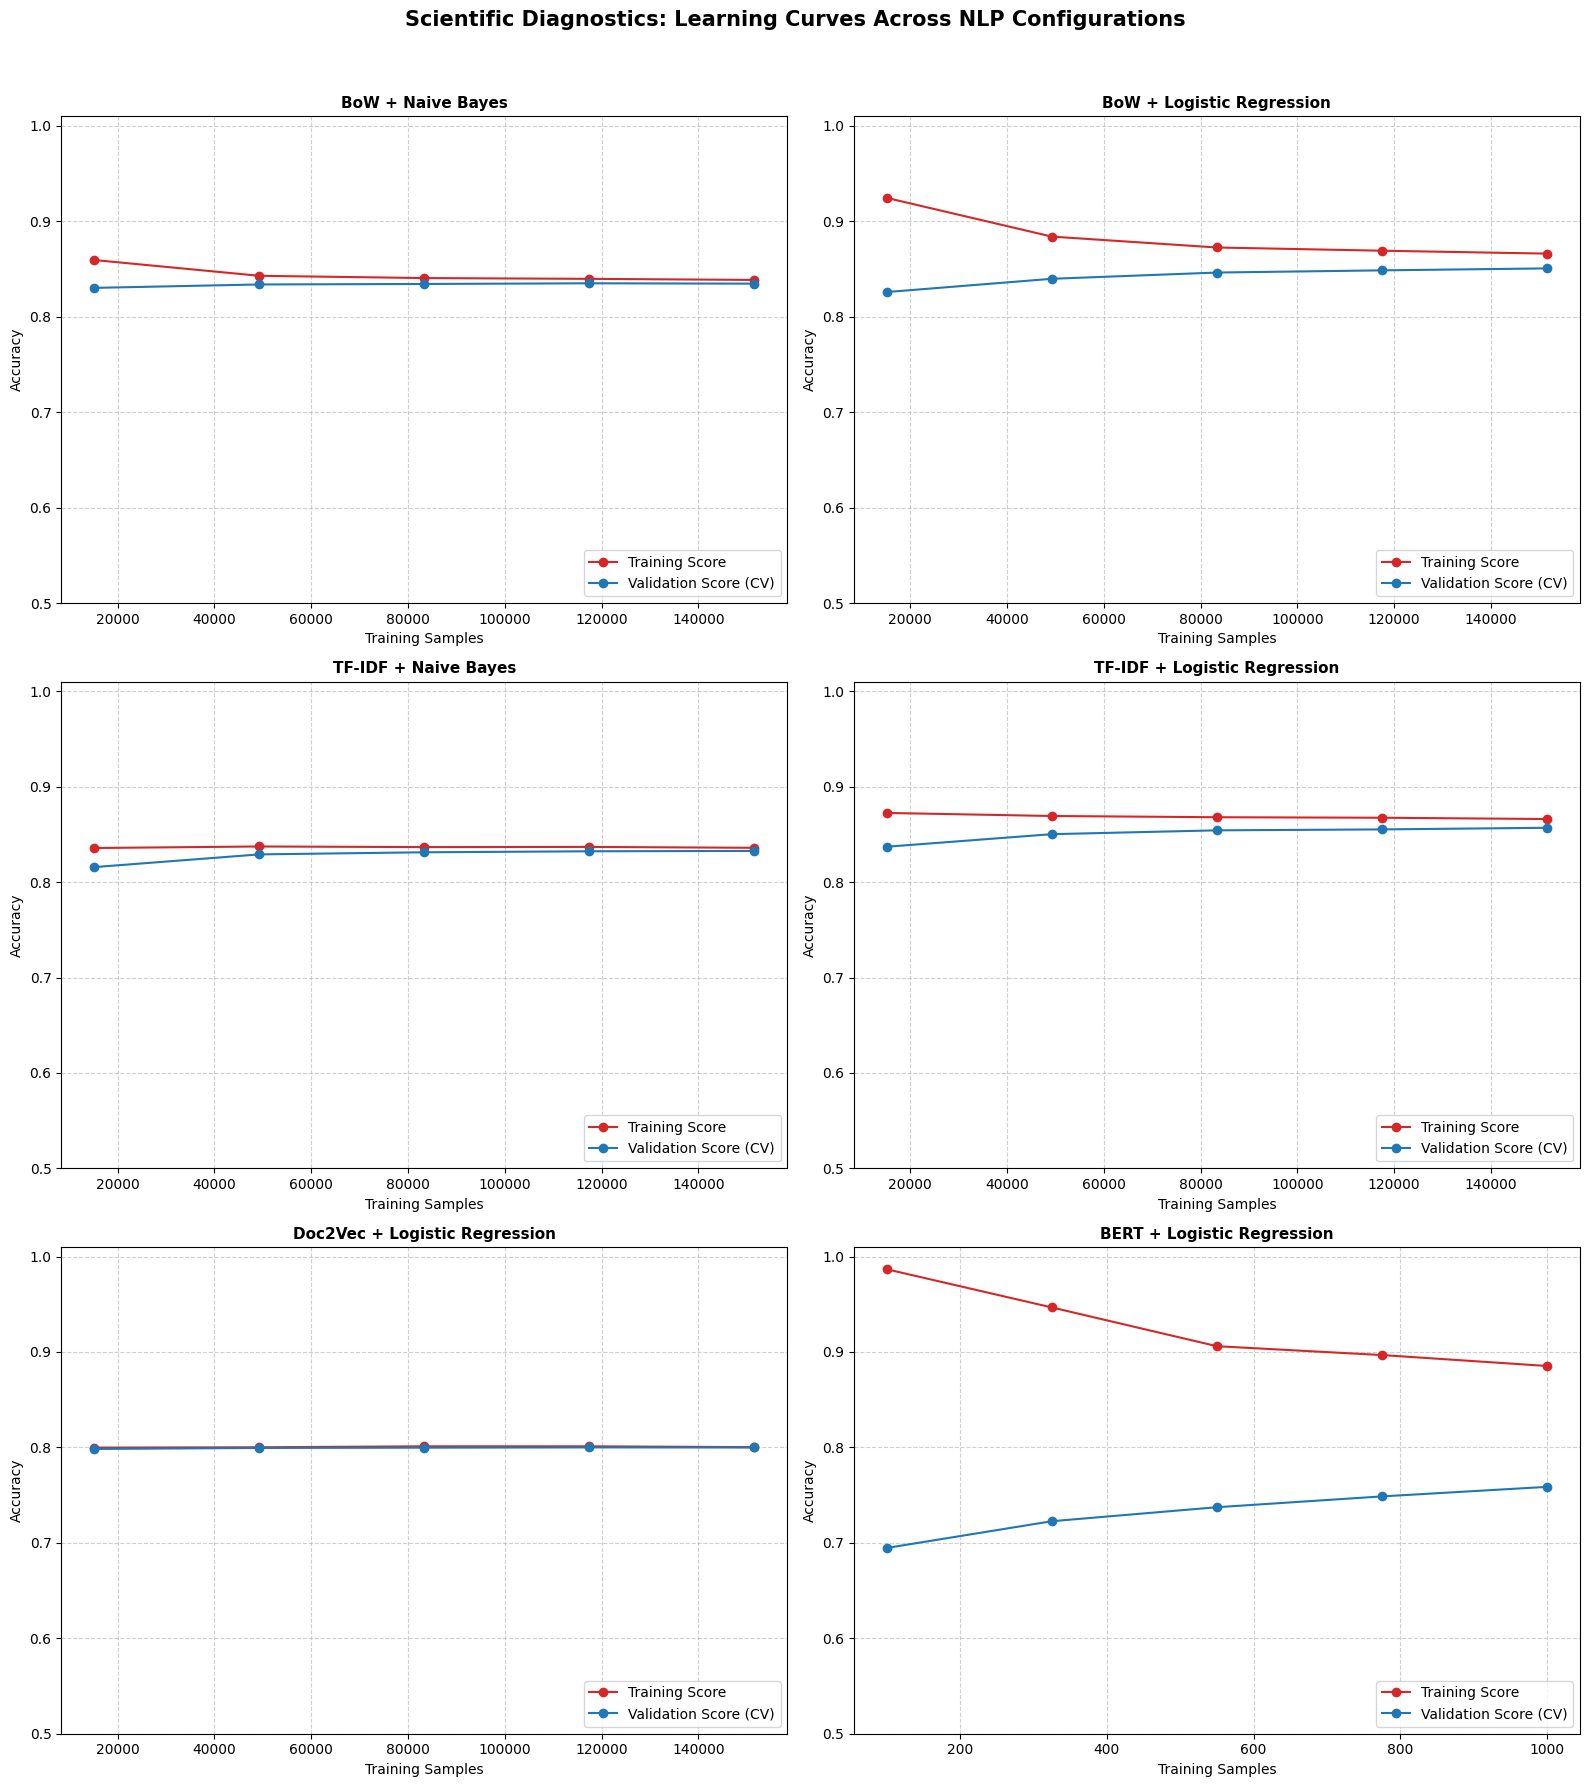

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_custom_learning_curve(model, X_data, y_data, title, ax):
    print(f"Computing Learning Curve for {title}...")

    # Evaluate the model at 5 different training sizes using 3-fold cross-validation
    # n_jobs=-1 automatically utilizes your local computer's multiple CPU cores
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_data, y_data,
        train_sizes=np.linspace(0.1, 1.0, 5),
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        random_state=42
    )

    # Calculate means
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    # Plot curves
    ax.plot(train_sizes, train_mean, 'o-', color="#d62728", label="Training Score")
    ax.plot(train_sizes, test_mean, 'o-', color="#1f77b4", label="Validation Score (CV)")

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel("Training Samples")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.50, 1.01) # Expanded scale to accommodate different baseline models safely
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc="lower right")

# Set up a 3x2 grid for the 6 text configurations to compare all approaches
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Row 1: Bag of Words (BoW) - Using the full available dataset splits
plot_custom_learning_curve(nb_bow, X_train_bow, y_train, "BoW + Naive Bayes", axes[0, 0])
plot_custom_learning_curve(lr_bow, X_train_bow, y_train, "BoW + Logistic Regression", axes[0, 1])

# Row 2: TF-IDF - Using the full available dataset splits
plot_custom_learning_curve(nb_tfidf, X_train_tfidf, y_train, "TF-IDF + Naive Bayes", axes[1, 0])
plot_custom_learning_curve(lr_tfidf, X_train_tfidf, y_train, "TF-IDF + Logistic Regression", axes[1, 1])

# Row 3: Advanced Semantic Embeddings (Doc2Vec and BERT)
# Optimization: Passing the sample-controlled feature matrices prevents high local CPU compute overhead
plot_custom_learning_curve(lr_d2v, X_train_d2v, y_train, "Doc2Vec + Logistic Regression", axes[2, 0])
plot_custom_learning_curve(lr_bert, X_train_bert, y_train_bert_sample, "BERT + Logistic Regression", axes[2, 1])

plt.suptitle("Scientific Diagnostics: Learning Curves Across NLP Configurations", fontsize=15, y=0.99, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### **Comparison of predictive text models with the text vectorization methods**

We consolidate the evaluation metrics for our text classifiers into a single comparative dataframe. In addition to general we display the accuracy, precision and recall. All scores are programmatically formatted as percentages to facilitate a clean, visual comparison between the Bag of Words, TF-IDF, Doc2Vec, and BERT pipelines across both Naive Bayes and Logistic Regression models. Multinomial Naive Bayes cannot be applied to BERT or Doc2Vec because it requires non-negative frequency counts, making it mathematically incompatible with the continuous dense embeddings that contain negative vector values.

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Compile results from all text vectorization methodologies and architectures
results = [
    {
        "Vectorization": "Bag of Words (BoW)", "Model": "Naive Bayes",
        "Accuracy": accuracy_score(y_test, preds_nb_bow),
        "Precision": precision_score(y_test, preds_nb_bow),
        "Recall": recall_score(y_test, preds_nb_bow),
        "F1-Score": f1_score(y_test, preds_nb_bow)
    },
    {
        "Vectorization": "Bag of Words (BoW)", "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, preds_lr_bow),
        "Precision": precision_score(y_test, preds_lr_bow),
        "Recall": recall_score(y_test, preds_lr_bow),
        "F1-Score": f1_score(y_test, preds_lr_bow)
    },
    {
        "Vectorization": "TF-IDF", "Model": "Naive Bayes",
        "Accuracy": accuracy_score(y_test, preds_nb_tfidf),
        "Precision": precision_score(y_test, preds_nb_tfidf),
        "Recall": recall_score(y_test, preds_nb_tfidf),
        "F1-Score": f1_score(y_test, preds_nb_tfidf)
    },
    {
        "Vectorization": "TF-IDF", "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, preds_lr_tfidf),
        "Precision": precision_score(y_test, preds_lr_tfidf),
        "Recall": recall_score(y_test, preds_lr_tfidf),
        "F1-Score": f1_score(y_test, preds_lr_tfidf)
    },
    {
        "Vectorization": "Doc2Vec", "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, preds_lr_d2v),
        "Precision": precision_score(y_test, preds_lr_d2v),
        "Recall": recall_score(y_test, preds_lr_d2v),
        "F1-Score": f1_score(y_test, preds_lr_d2v)
    },
    {
        "Vectorization": "BERT (Sample)", "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test_bert_sample, preds_lr_bert),
        "Precision": precision_score(y_test_bert_sample, preds_lr_bert),
        "Recall": recall_score(y_test_bert_sample, preds_lr_bert),
        "F1-Score": f1_score(y_test_bert_sample, preds_lr_bert)
    }
]

df_results = pd.DataFrame(results)

# Display a clean evaluation matrix
print("="*85)
print("                               MODEL COMPARISON REPORT")
print("="*85)
print(df_results.to_string(index=False, formatters={
    'Accuracy': '{:,.2%}'.format,
    'Precision': '{:,.2%}'.format,
    'Recall': '{:,.2%}'.format,
    'F1-Score': '{:,.2%}'.format
}))
print("="*85)

                               MODEL COMPARISON REPORT
     Vectorization               Model Accuracy Precision Recall F1-Score
Bag of Words (BoW)         Naive Bayes   83.49%    89.31% 88.55%   88.93%
Bag of Words (BoW) Logistic Regression   85.32%    86.99% 94.54%   90.61%
            TF-IDF         Naive Bayes   83.43%    83.07% 97.81%   89.84%
            TF-IDF Logistic Regression   85.76%    87.59% 94.36%   90.85%
           Doc2Vec Logistic Regression   78.06%    78.13% 98.19%   87.02%
     BERT (Sample) Logistic Regression   75.00%    79.41% 89.71%   84.25%


### **Confussion Matrix for text predictive models**

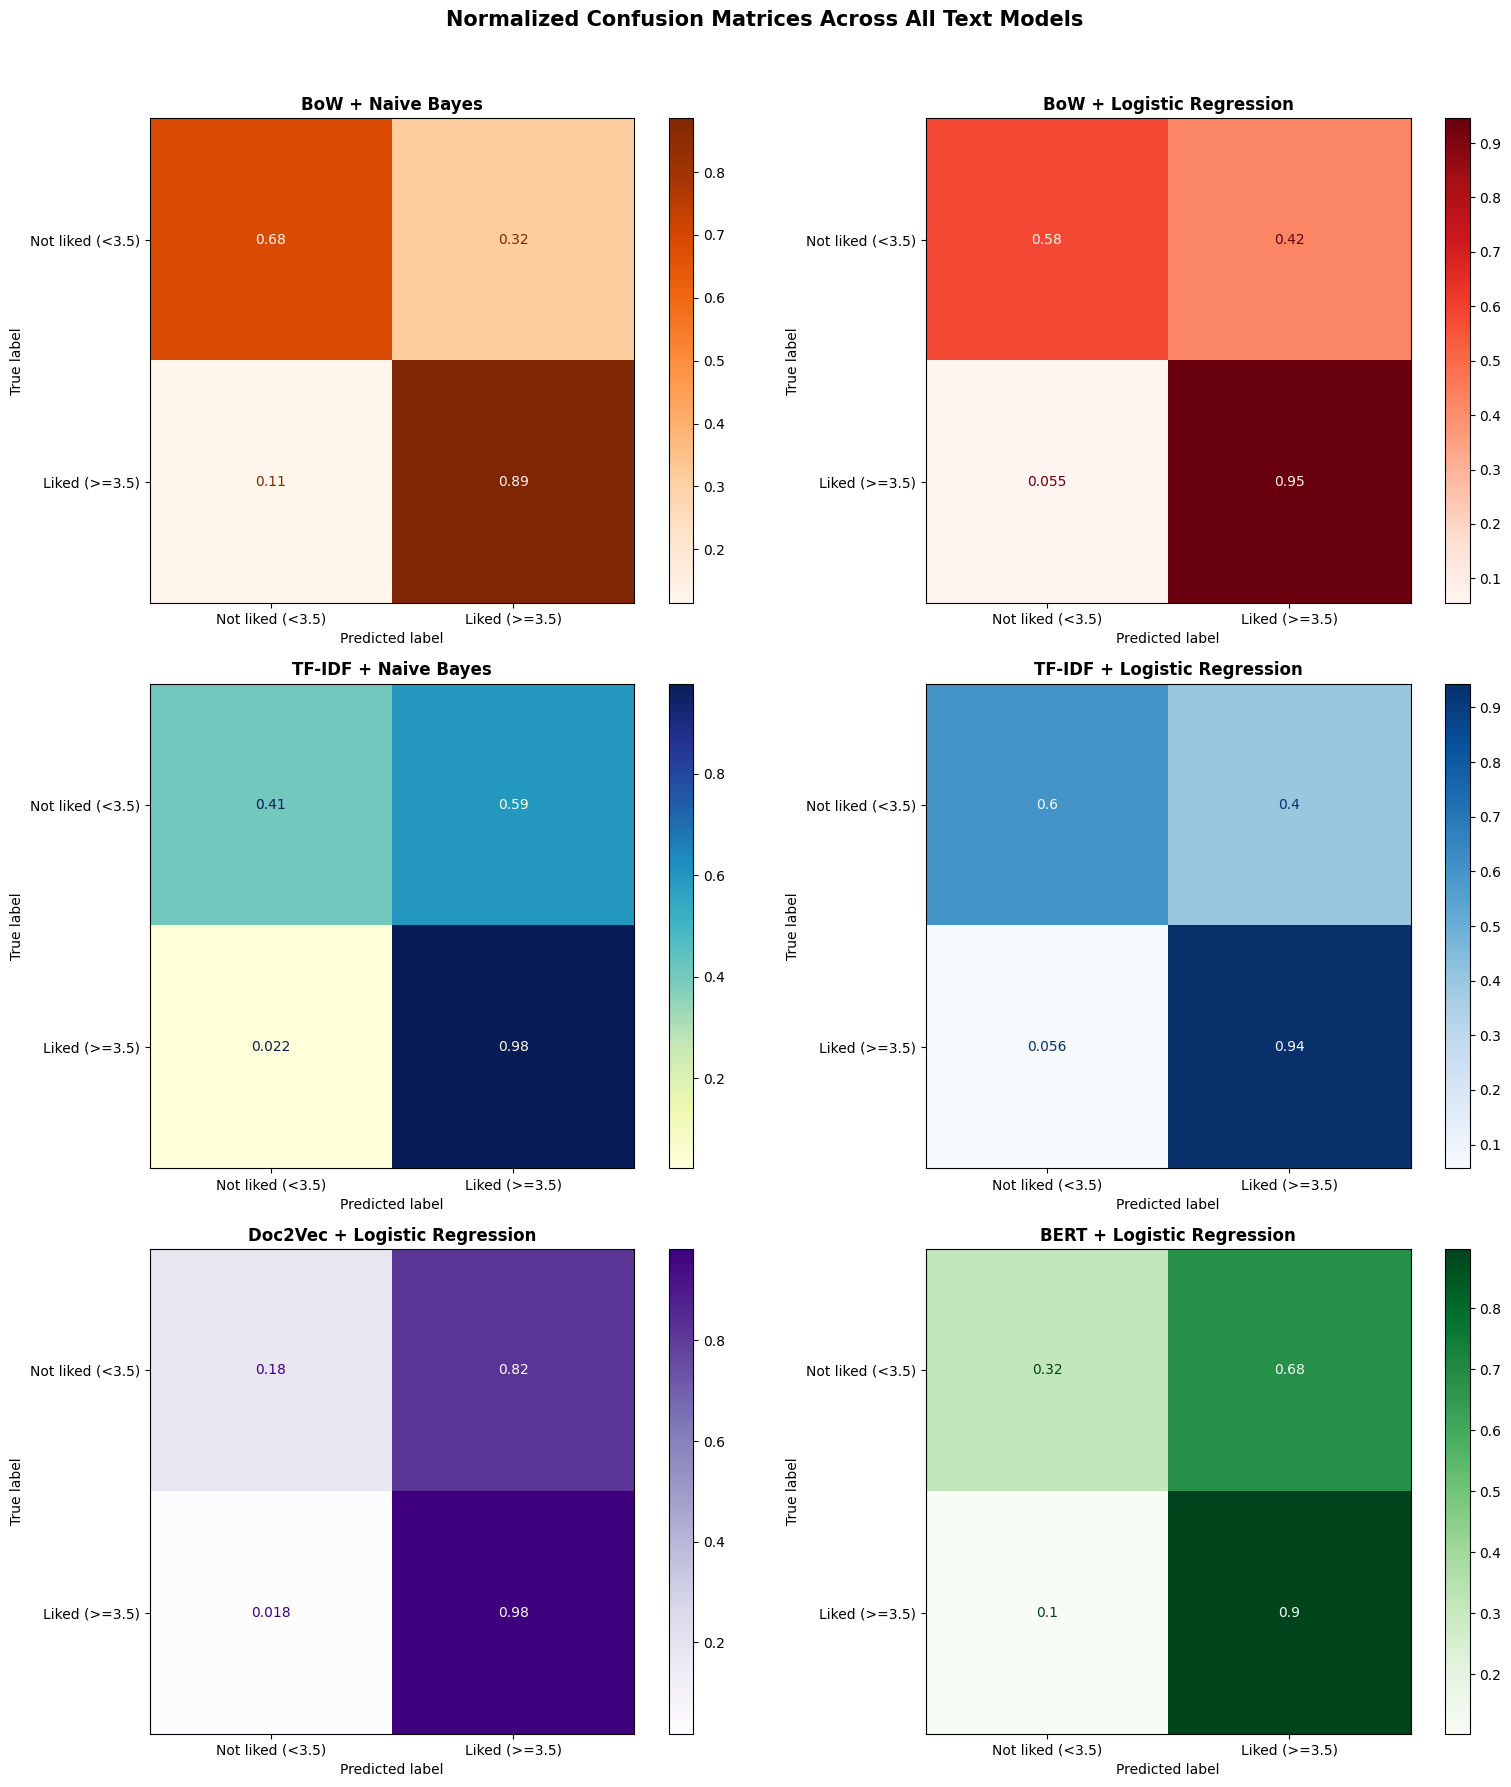

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Set up a 3x2 grid to display all 6 configurations for comprehensive comparison
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# --- ROW 1: BAG OF WORDS (BoW) ---
# axes[0, 0]: BoW + Naive Bayes
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_nb_bow,
    display_labels=["Not liked (<3.5)", "Liked (>=3.5)"],
    ax=axes[0, 0], cmap='Oranges', normalize='true'
)
axes[0, 0].set_title("BoW + Naive Bayes", fontsize=12, fontweight='bold')

# axes[0, 1]: BoW + Logistic Regression
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_lr_bow,
    display_labels=["Not liked (<3.5)", "Liked (>=3.5)"],
    ax=axes[0, 1], cmap='Reds', normalize='true'
)
axes[0, 1].set_title("BoW + Logistic Regression", fontsize=12, fontweight='bold')


# --- ROW 2: TF-IDF ---
# axes[1, 0]: TF-IDF + Naive Bayes
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_nb_tfidf,
    display_labels=["Not liked (<3.5)", "Liked (>=3.5)"],
    ax=axes[1, 0], cmap='YlGnBu', normalize='true'
)
axes[1, 0].set_title("TF-IDF + Naive Bayes", fontsize=12, fontweight='bold')

# axes[1, 1]: TF-IDF + Logistic Regression
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_lr_tfidf,
    display_labels=["Not liked (<3.5)", "Liked (>=3.5)"],
    ax=axes[1, 1], cmap='Blues', normalize='true'
)
axes[1, 1].set_title("TF-IDF + Logistic Regression", fontsize=12, fontweight='bold')


# --- ROW 3: ADVANCED SEMANTIC EMBEDDINGS ---
# axes[2, 0]: Doc2Vec + Logistic Regression
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_lr_d2v,
    display_labels=["Not liked (<3.5)", "Liked (>=3.5)"],
    ax=axes[2, 0], cmap='Purples', normalize='true'
)
axes[2, 0].set_title("Doc2Vec + Logistic Regression", fontsize=12, fontweight='bold')

# axes[2, 1]: BERT + Logistic Regression
# Note: Using sample-specific labels to match the reduced BERT validation dimensions
ConfusionMatrixDisplay.from_predictions(
    y_test_bert_sample, preds_lr_bert,
    display_labels=["Not liked (<3.5)", "Liked (>=3.5)"],
    ax=axes[2, 1], cmap='Greens', normalize='true'
)
axes[2, 1].set_title("BERT + Logistic Regression", fontsize=12, fontweight='bold')


plt.suptitle("Normalized Confusion Matrices Across All Text Models", fontsize=15, y=0.99, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

---

# **Numeric predicting models**

## **Classification Framework for Sentiment and Satisfaction Prediction**

In this section, we prepare our numerical dataset to train the Decision Tree, Random Forest, and Gradient Boosting classifiers. We extract the release_year from the date metadata and perform median imputation to clean any missing entries in our continuous features. The final matrix isolates four strategic indicators: movie duration, release year, and review interactions (likes/dislikes). This numerical subset is mapped against our binary satisfaction target (is_liked) to evaluate predictive performance outside of the textual domain.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

print("Preparing features")

# 1. Extract the current year of realease
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
# Fill empty values
df['release_year'] = df['release_year'].fillna(df['release_year'].median())

# 2. Define the input columns  (X_num) and output ones (y)
numerical_features = ['runtime_in_minutes', 'likes', 'dislikes', 'release_year']
X_num = df[numerical_features].copy()

# Fill any empty value
X_num['runtime_in_minutes'] = X_num['runtime_in_minutes'].fillna(X_num['runtime_in_minutes'].median())

# 3. We reuse the target defined in first step
y_num = df['is_liked']

print(f"Numeric variables ready to train: {numerical_features}")

Preparing features
Numeric variables ready to train: ['runtime_in_minutes', 'likes', 'dislikes', 'release_year']


### **Numeric Model training**

We separate the tests and training set for the numeric data

In [ ]:
X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(
    X_num, y_num, test_size=0.2, random_state=42, stratify=y_num
)

print(f"Training numeric set: {X_train_num.shape[0]}")
print(f"Testing numeric set: {X_test_num.shape[0]} ")


Training numeric set: 227387
Testing numeric set: 56847 


We train three supervised tree-based algorithms on our numerical features: Decision Tree, Random Forest, and Gradient Boosting. Hyper-parameters such as max_depth and n_estimators are explicitly defined to control model complexity and avoid over-fitting. After fitting the data, each classifier predicts user satisfaction (is_liked) on the test set, allowing us to compare a single rule-based model against parallel and sequential ensemble methods.

In [ ]:
print("Training Decision Tree...")
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_num, y_train_num)
preds_dt = dt_model.predict(X_test_num)

print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train_num, y_train_num)
preds_rf = rf_model.predict(X_test_num)

print("Training Gradient Boosting (Boosting)...")
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train_num, y_train_num)
preds_gb = gb_model.predict(X_test_num)

print("All models trained succesfully")

Training Decision Tree...
Training Random Forest...
Training Gradient Boosting (Boosting)...
All models trained succesfully


### **Learning curve for numerical models**

This section generates a $1 \times 3$ grid comparing the learning curves of our tree-based tabular models: Decision Tree, Random Forest, and Gradient Boosting

Computing Learning Curve for Decision Tree (Numerical)...
Computing Learning Curve for Random Forest (Numerical)...
Computing Learning Curve for Gradient Boosting (Numerical)...


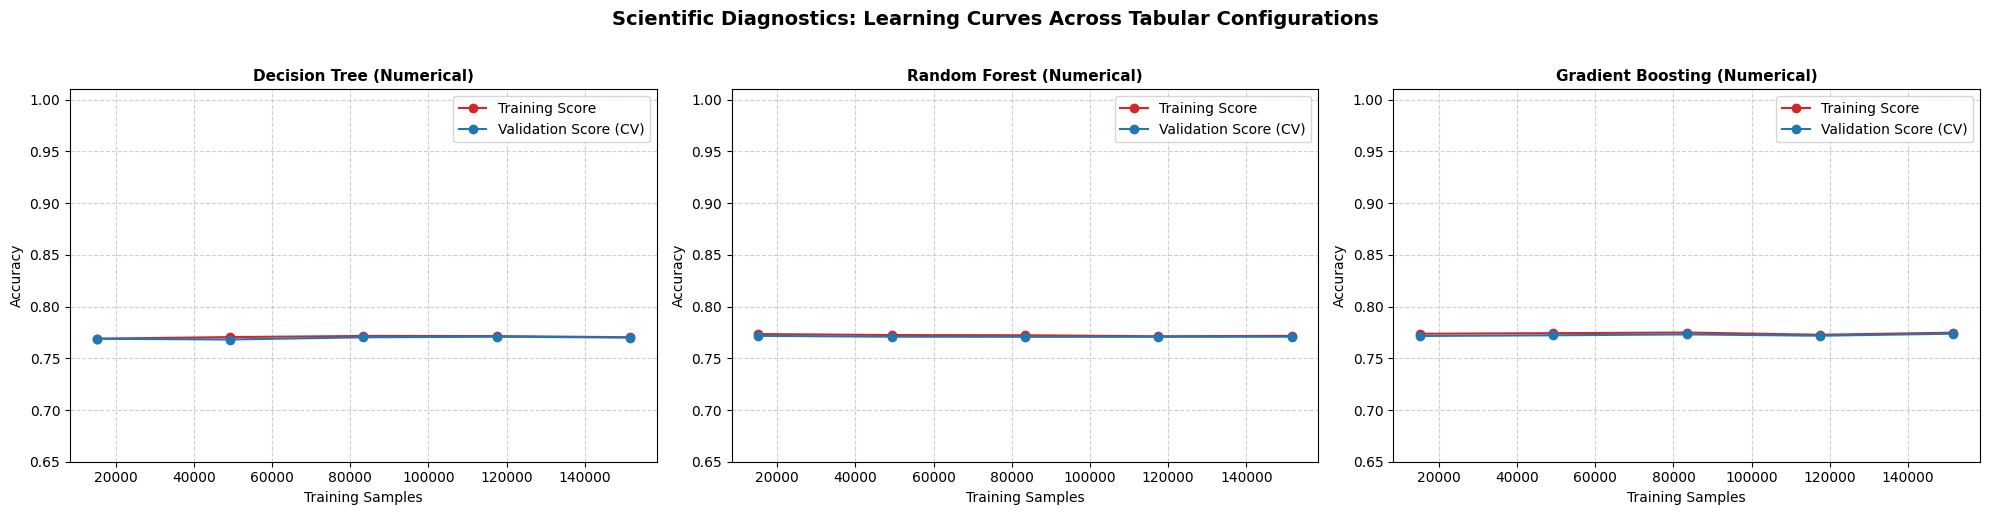

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_custom_learning_curve(model, X_data, y_data, title, ax):
    print(f"Computing Learning Curve for {title}...")

    # Evaluate the model at 5 different training sizes using 3-fold cross-validation
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_data, y_data,
        train_sizes=np.linspace(0.1, 1.0, 5),
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        random_state=42
    )

    # Calculate means
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    # Plot curves
    ax.plot(train_sizes, train_mean, 'o-', color="#d62728", label="Training Score")
    ax.plot(train_sizes, test_mean, 'o-', color="#1f77b4", label="Validation Score (CV)")

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel("Training Samples")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.65, 1.01) # Focused scale matching the text models for fair comparison
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc="best")

# Set up a 1x3 grid for the 3 numerical models
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plotting each tree-based model
plot_custom_learning_curve(dt_model, X_train_num, y_train_num, "Decision Tree (Numerical)", axes[0])
plot_custom_learning_curve(rf_model, X_train_num, y_train_num, "Random Forest (Numerical)", axes[1])
plot_custom_learning_curve(gb_model, X_train_num, y_train_num, "Gradient Boosting (Numerical)", axes[2])

plt.suptitle("Scientific Diagnostics: Learning Curves Across Tabular Configurations", fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

### **Comparison of predictive numerical models**

This block compiles the final performance report for our tabular pipeline, incorporating Precision and Recall metrics alongside Accuracy and F1-Score.

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

num_results = [
    {
        "Model (Numerical Data)": "Decision Tree",
        "Accuracy": accuracy_score(y_test_num, preds_dt),
        "Precision": precision_score(y_test_num, preds_dt),
        "Recall": recall_score(y_test_num, preds_dt),
        "F1-Score": f1_score(y_test_num, preds_dt)
    },
    {
        "Model (Numerical Data)": "Random Forest",
        "Accuracy": accuracy_score(y_test_num, preds_rf),
        "Precision": precision_score(y_test_num, preds_rf),
        "Recall": recall_score(y_test_num, preds_rf),
        "F1-Score": f1_score(y_test_num, preds_rf)
    },
    {
        "Model (Numerical Data)": "Gradient Boosting (Boosting)",
        "Accuracy": accuracy_score(y_test_num, preds_gb),
        "Precision": precision_score(y_test_num, preds_gb),
        "Recall": recall_score(y_test_num, preds_gb),
        "F1-Score": f1_score(y_test_num, preds_gb)
    },
]

df_num_results = pd.DataFrame(num_results)

print("="*85)
print("🏆                  NUMERICAL MODELS COMPARISON REPORT (STAGE 5)")
print("="*85)
print(df_num_results.to_string(index=False, formatters={
    'Accuracy': '{:,.2%}'.format,
    'Precision': '{:,.2%}'.format,
    'Recall': '{:,.2%}'.format,
    'F1-Score': '{:,.2%}'.format
}))
print("="*85)

🏆                  NUMERICAL MODELS COMPARISON REPORT (STAGE 5)
      Model (Numerical Data) Accuracy Precision Recall F1-Score
               Decision Tree   76.93%    78.23% 95.88%   86.16%
               Random Forest   76.88%    77.77% 96.78%   86.24%
Gradient Boosting (Boosting)   77.19%    77.86% 97.16%   86.45%


### **Confussion Matrix for numerical predictive models**

This section generates a $1 \times 3$ grid of normalized confusion matrices to visually inspect the error distribution across our tabular architectures

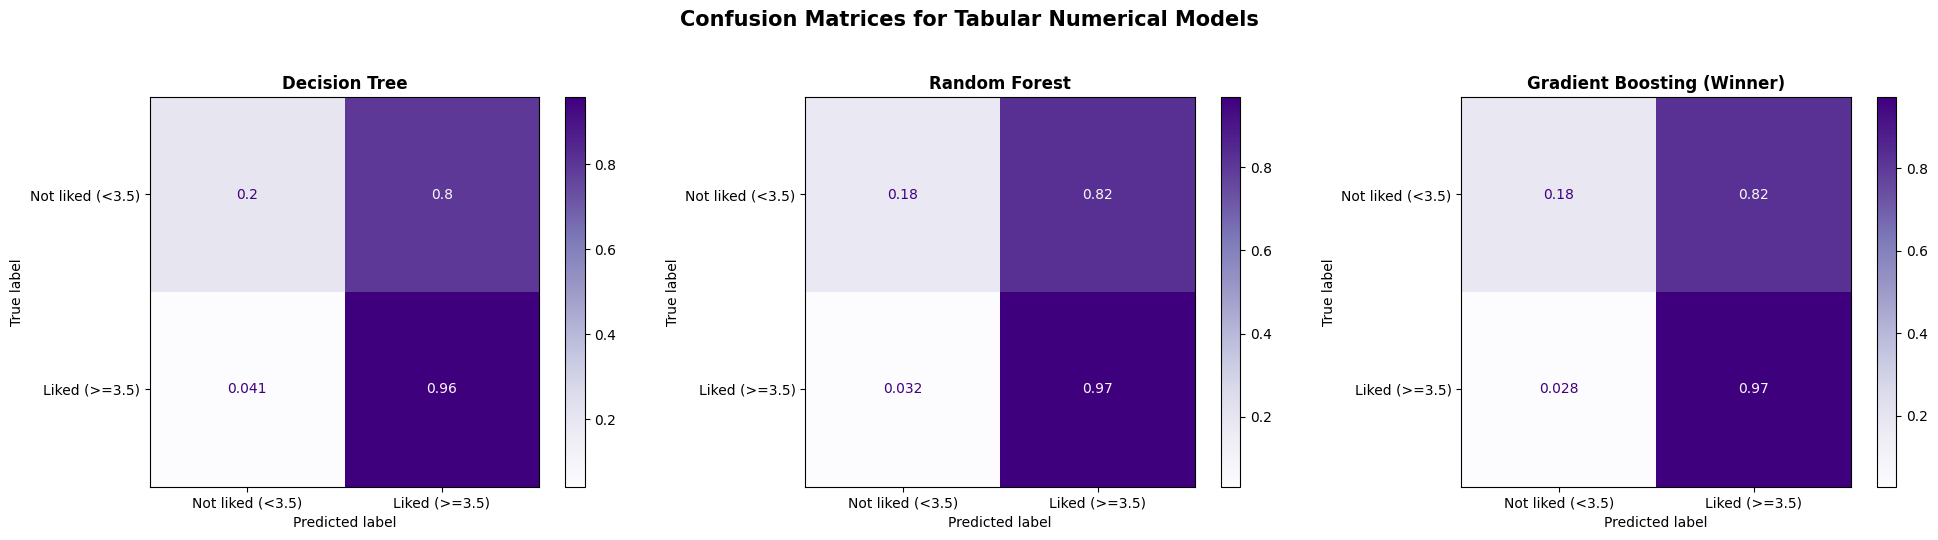

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Set up a 1x3 grid for the 3 numerical models
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Decision Tree Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test_num, preds_dt,
    display_labels=["Not liked (<3.5)", "Liked (>=3.5)"],
    ax=axes[0], cmap='Purples', normalize='true'
)
axes[0].set_title("Decision Tree", fontsize=12, fontweight='bold')

# 2. Random Forest Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test_num, preds_rf,
    display_labels=["Not liked (<3.5)", "Liked (>=3.5)"],
    ax=axes[1], cmap='Purples', normalize='true'
)
axes[1].set_title("Random Forest", fontsize=12, fontweight='bold')

# 3. Gradient Boosting Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test_num, preds_gb,
    display_labels=["Not liked (<3.5)", "Liked (>=3.5)"],
    ax=axes[2], cmap='Purples', normalize='true'
)
axes[2].set_title("Gradient Boosting (Winner)", fontsize=12, fontweight='bold')

plt.suptitle("Confusion Matrices for Tabular Numerical Models", fontsize=15, y=1.05, fontweight='bold')
plt.tight_layout()
plt.show()

### **Decission process for numerical training models**

We extract and visualize the internal decision-making process of our top-performing tabular algorithm through its Feature Importance attributes. By computing how much each split on a specific variable reduces the overall impurity (GINI or Mean Squared Error) across all 100 sequential trees, the Gradient Boosting model ranks our numerical features by their actual predictive power. This visualization serves as an interpretability layer, allowing us to scientifically verify whether the model relies on community validation metrics (likes/dislikes) or metadata attributes (runtime/release_year) to determine user satisfaction.

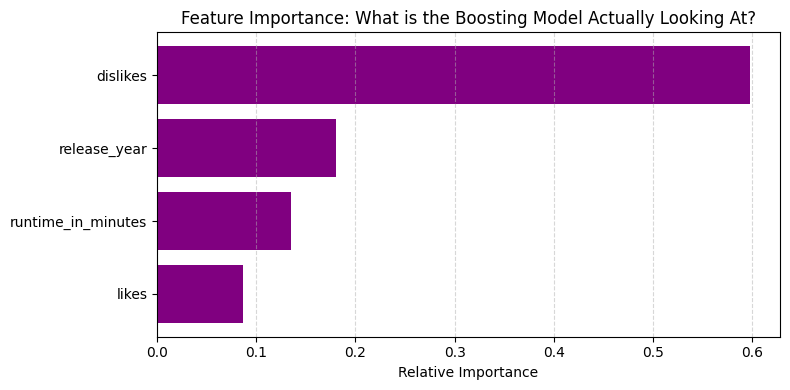

In [ ]:
importances = gb_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': numerical_features, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'], color='purple')
plt.xlabel('Relative Importance')
plt.title('Feature Importance: What is the Boosting Model Actually Looking At?')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---

## **Predictive Modeling for Review Relevance & Cold Start Optimization**

In this section, we change our approach to a numerical regression model. The goal is to solve the cold start problem for new reviews. Instead of predicting if a user liked the movie, we predict how popular the review will be by targeting the `likes_ratio`.

We create new numerical features from our 284,000 rows to help the models learn better:

* **Rating Deviation:** We calculate the average rating of each movie using `movie_id`. Then, we find the difference between the user's score and that average.
* **Review Length:** We calculate the total number of characters in the text.
* **Years Since Release:** We measure the time passed between the movie premiere and the review date.
* **Genres:** We transform the list of movie genres into separate binary columns (0 or 1).

This final numerical matrix is used to train our tree-based regression models before doing any natural language processing.

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

print("Preparing features and target for numerical regression models")

# 1. Fill missing values for columns already present in the preprocessed dataset
df['text_content'] = df['text_content'].fillna("")
df['runtime_in_minutes'] = df['runtime_in_minutes'].fillna(df['runtime_in_minutes'].median())

# 2. Global movie ranking context using 'movie_id' instead of 'id'
# This aggregates ratings across all 284k rows to find the baseline of each film
global_movie_means = df.groupby('movie_id')['rating'].mean()
df['movie_average_rating'] = df['movie_id'].map(global_movie_means)

# Calculate the deviation metric (how much this review disagrees with the general consensus)
df['rating_deviation'] = df['rating'] - df['movie_average_rating']

# 3. One-Hot Encoding for Movie Genres
# Explode the genres array list and create dummy columns
genres_dummies = df['genres'].explode().str.get_dummies().groupby(level=0).sum()

# To avoid duplicates if cell is re-run, check if genre columns exist before concatenating
new_genre_cols = [col for col in genres_dummies.columns if col not in df.columns]
if new_genre_cols:
    df = pd.concat([df, genres_dummies[new_genre_cols]], axis=1)

# Define final input features (X) and target (y)
genre_columns = list(genres_dummies.columns)
numerical_features = [
    'rating', 
    'rating_deviation', 
    'review_length', 
    'runtime_in_minutes', 
    'years_since_release'
] + genre_columns

X_num = df[numerical_features].copy()
y_num = df['likes_ratio'].fillna(0.0) # Ensure no missing targets

print(f"Total numeric features ready to train: {len(numerical_features)}")
print(f"Target distribution mean: {y_num.mean():.4f}")

Preparing features and target for numerical regression models
Total numeric features ready to train: 27
Target distribution mean: 0.1240


We separate the tests and training set for the numeric data

In [5]:
X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(
    X_num, y_num, test_size=0.2, random_state=42
)

print(f"Training numeric set rows: {X_train_num.shape[0]}")
print(f"Testing numeric set rows: {X_test_num.shape[0]}")

Training numeric set rows: 227387
Testing numeric set rows: 56847


We train three supervised tree-based algorithms on our numerical features: Decision Tree, Random Forest, and Gradient Boosting. 

In [6]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

print("Training Decision Tree Regressor...")
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train_num, y_train_num)
preds_dt = dt_model.predict(X_test_num)

print("Training Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train_num, y_train_num)
preds_rf = rf_model.predict(X_test_num)

print("Training Gradient Boosting Regressor...")
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train_num, y_train_num)
preds_gb = gb_model.predict(X_test_num)

print("All regression models trained successfully")

Training Decision Tree Regressor...
Training Random Forest Regressor...
Training Gradient Boosting Regressor...
All regression models trained successfully


### **Learning curve for numerical models**

This section generates a $1 \times 3$ grid comparing the learning curves of our tree-based tabular models: Decision Tree, Random Forest, and Gradient Boosting

Computing Learning Curve for Decision Tree (Numerical)...
Computing Learning Curve for Random Forest (Numerical)...
Computing Learning Curve for Gradient Boosting (Numerical)...


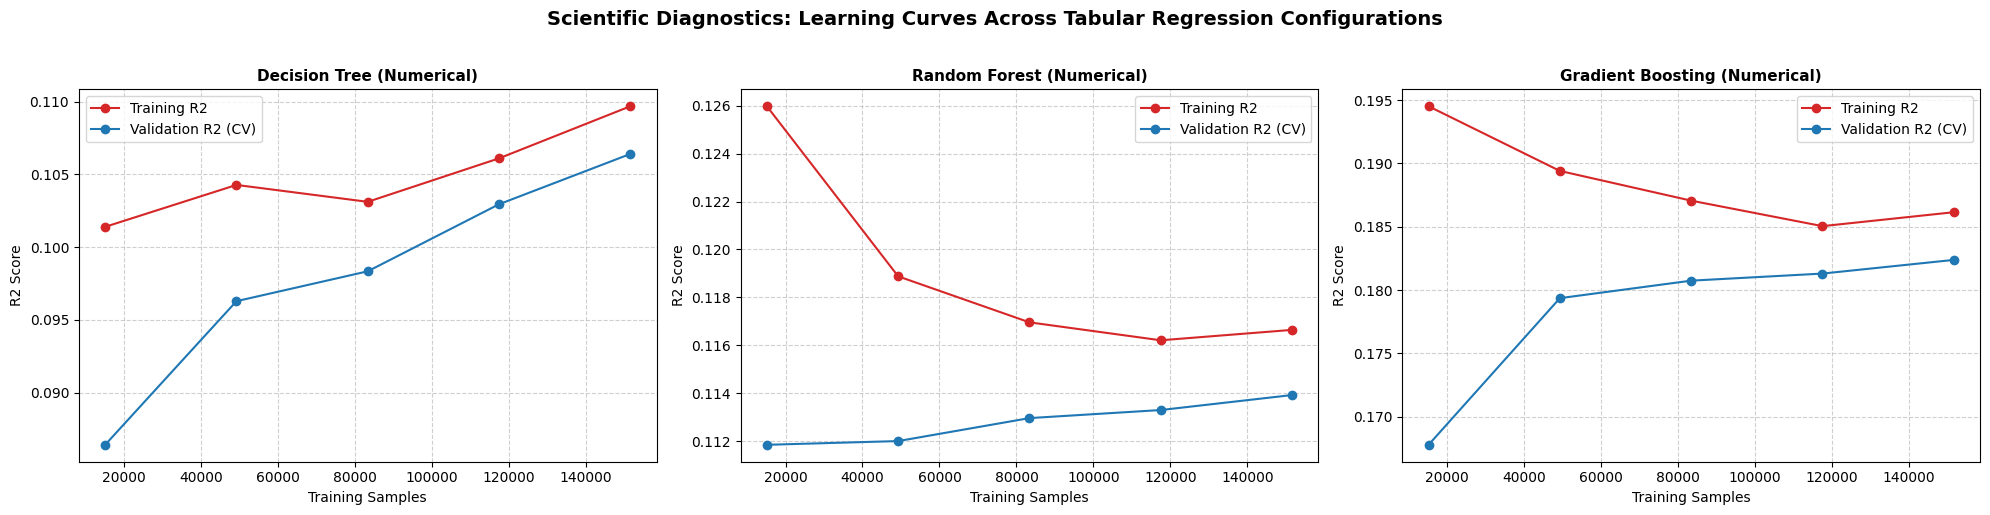

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_custom_learning_curve(model, X_data, y_data, title, ax):
    print(f"Computing Learning Curve for {title}...")

    # Evaluate the model at 5 training sizes using 3-fold cross-validation with R2 metric
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_data, y_data,
        train_sizes=np.linspace(0.1, 1.0, 5),
        cv=3,
        scoring='r2',
        n_jobs=-1,
        random_state=42
    )

    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color="#d62728", label="Training R2")
    ax.plot(train_sizes, test_mean, 'o-', color="#1f77b4", label="Validation R2 (CV)")

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel("Training Samples")
    ax.set_ylabel("R2 Score")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc="best")

# Set up a 1x3 grid for the 3 numerical models
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

plot_custom_learning_curve(dt_model, X_train_num, y_train_num, "Decision Tree (Numerical)", axes[0])
plot_custom_learning_curve(rf_model, X_train_num, y_train_num, "Random Forest (Numerical)", axes[1])
plot_custom_learning_curve(gb_model, X_train_num, y_train_num, "Gradient Boosting (Numerical)", axes[2])

plt.suptitle("Scientific Diagnostics: Learning Curves Across Tabular Regression Configurations", fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

### **Comparison of predictive numerical models**

This block compiles the final performance report for our regression pipeline, incorporating $R^2$ Score and Mean Absolute Error (MAE) alongside MSE and RMSE to evaluate continuous prediction accuracy.

In [8]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Compute traditional regression metric evaluations for each trained configuration
num_results = [
    {
        "Model (Numerical Data)": "Decision Tree",
        "R2 Score": r2_score(y_test_num, preds_dt),
        "MAE (Avg Error)": mean_absolute_error(y_test_num, preds_dt),
        "MSE": mean_squared_error(y_test_num, preds_dt),
        "RMSE": np.sqrt(mean_squared_error(y_test_num, preds_dt))
    },
    {
        "Model (Numerical Data)": "Random Forest",
        "R2 Score": r2_score(y_test_num, preds_rf),
        "MAE (Avg Error)": mean_absolute_error(y_test_num, preds_rf),
        "MSE": mean_squared_error(y_test_num, preds_rf),
        "RMSE": np.sqrt(mean_squared_error(y_test_num, preds_rf))
    },
    {
        "Model (Numerical Data)": "Gradient Boosting",
        "R2 Score": r2_score(y_test_num, preds_gb),
        "MAE (Avg Error)": mean_absolute_error(y_test_num, preds_gb),
        "MSE": mean_squared_error(y_test_num, preds_gb),
        "RMSE": np.sqrt(mean_squared_error(y_test_num, preds_gb))
    },
]

df_num_results = pd.DataFrame(num_results)

# Display tabular data with standard styling adjustments
print("="*95)
print("NUMERICAL REGRESSION MODELS COMPARISON REPORT (STAGE 5)")
print("="*95)
print(df_num_results.to_string(index=False, formatters={
    'R2 Score': '{:,.2%}'.format,
    'MAE (Avg Error)': '{:,.4f}'.format,
    'MSE': '{:,.4f}'.format,
    'RMSE': '{:,.4f}'.format
}))
print("="*95)

NUMERICAL REGRESSION MODELS COMPARISON REPORT (STAGE 5)
Model (Numerical Data) R2 Score MAE (Avg Error)    MSE   RMSE
         Decision Tree   10.57%          0.1681 0.0466 0.2160
         Random Forest   11.32%          0.1682 0.0462 0.2151
     Gradient Boosting   17.81%          0.1592 0.0429 0.2070


### **Confussion Matrix for numerical predictive models**

This section generates a $1 \times 3$ grid of residual scatter plots to visually inspect the error distribution and model alignment against the perfect diagonal prediction line across our tabular regression architectures.

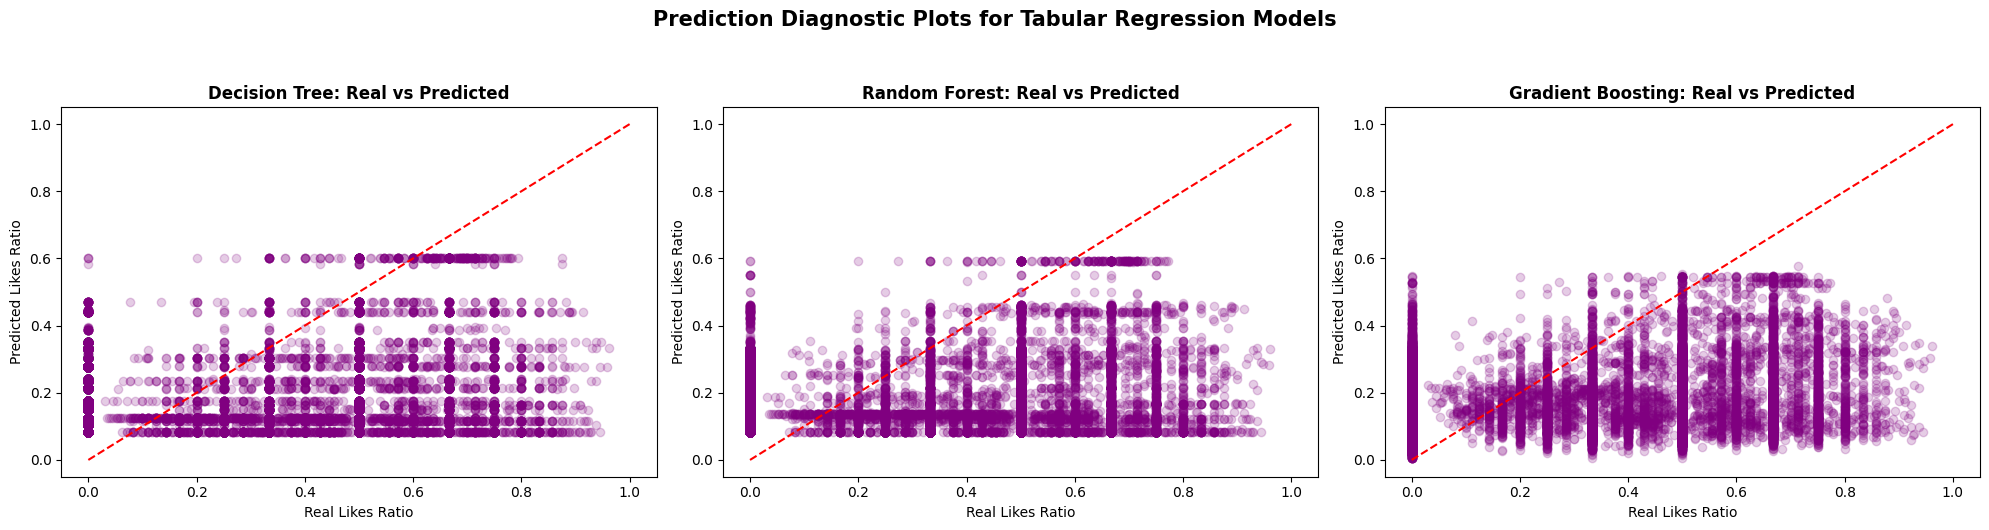

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Decision Tree Residuals
axes[0].scatter(y_test_num, preds_dt, alpha=0.2, color='purple')
axes[0].plot([0, 1], [0, 1], '--', color='red')
axes[0].set_title("Decision Tree: Real vs Predicted", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Real Likes Ratio")
axes[0].set_ylabel("Predicted Likes Ratio")

# 2. Random Forest Residuals
axes[1].scatter(y_test_num, preds_rf, alpha=0.2, color='purple')
axes[1].plot([0, 1], [0, 1], '--', color='red')
axes[1].set_title("Random Forest: Real vs Predicted", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Real Likes Ratio")
axes[1].set_ylabel("Predicted Likes Ratio")

# 3. Gradient Boosting Residuals
axes[2].scatter(y_test_num, preds_gb, alpha=0.2, color='purple')
axes[2].plot([0, 1], [0, 1], '--', color='red')
axes[2].set_title("Gradient Boosting: Real vs Predicted", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Real Likes Ratio")
axes[2].set_ylabel("Predicted Likes Ratio")

plt.suptitle("Prediction Diagnostic Plots for Tabular Regression Models", fontsize=15, y=1.05, fontweight='bold')
plt.tight_layout()
plt.show()

### **Decission process for numerical training models**

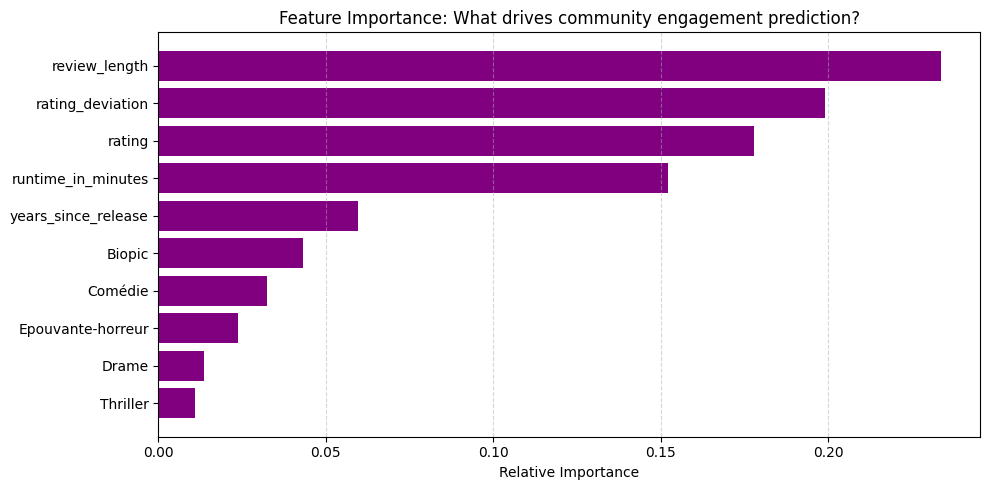

In [10]:
importances = gb_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': numerical_features, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# Select the top 10 variables to keep the plot clean
top_features = feature_imp_df.head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_features['Feature'], top_features['Importance'], color='purple')
plt.xlabel('Relative Importance')
plt.title('Feature Importance: What drives community engagement prediction?')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()